# Desarrollo y obtención de características derivadas

### Importación de Módulos

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import json
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score
from scipy.sparse import csr_matrix, hstack
import lightgbm as lgb

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

### Carga de datasets

In [10]:
df_cleaned = pd.read_csv("../data/gen9ou_cleaned_no_duplicates.csv")
df_cleaned.head()

,battle_id,p1_poke1,p1_poke2,p1_poke3,p1_poke4,p1_poke5,p1_poke6,p2_poke1,p2_poke2,p2_poke3,p2_poke4,p2_poke5,p2_poke6,p1_win
0,83362-gen9ou-2484742250,Krookodile,Kommo-o,Araquanid,Inteleon,Noivern,Muk-Alola,Alomomola,Slowking-Galar,Corviknight,Garchomp,Hatterene,Dragonite,1
1,gen9ou-2008544089,Ninetales-Alola,Manaphy,Kommo-o,Iron Valiant,Samurott-Hisui,Kingambit,Pawmot,Samurott-Hisui,Toxapex,Walking Wake,Empoleon,Great Tusk,1
2,gen9ou-2032727153,Serperior,Darkrai,Zapdos,Dragapult,Iron Valiant,Kingambit,Cresselia,Garganacl,Blissey,Dondozo,Skarmory,Breloom,1
3,gen9ou-2301833199,Ogerpon-Wellspring,Gholdengo,Glimmora,Raging Bolt,Iron Moth,Dragonite,Pelipper,Talonflame,Barraskewda,Zapdos,Manaphy,Bellibolt,1
4,gen9ou-2346353253,Garchomp,Slowking-Galar,Gholdengo,Moltres,Iron Valiant,Kingambit,Ceruledge,Rillaboom,Hatterene,Great Tusk,Scizor,Hawlucha,1


In [11]:
pokemon_stats_df = pd.read_csv("../data/OUStats.csv")
pokemon_stats_df.head()

,ID,Name,Form,Type1,Type2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
0,1,Bulbasaur,,Grass,Poison,318,45,49,49,65,65,45,1
1,2,Ivysaur,,Grass,Poison,405,60,62,63,80,80,60,1
2,3,Venusaur,,Grass,Poison,525,80,82,83,100,100,80,1
3,4,Charmander,,Fire,,309,39,52,43,60,50,65,1
4,5,Charmeleon,,Fire,,405,58,64,58,80,65,80,1


## 1. Estadísticas individuales, medias, máximas y mínimas de cada equipo

### 1.1 Estadísticas individuales 

A continuación se ejecutan funciones necesarias para el mapeo de nombres de Pokémon al dataset de estadísticas

In [12]:
import json

with open("../mapping/mapping.json", "r") as f:
    name_mapping = json.load(f)

# Crear diccionarios rápidos
map_target = {k: v["target_name"] for k, v in name_mapping.items()}
map_form = {k: v.get("form", None) for k, v in name_mapping.items()}

In [13]:
import unicodedata

def remove_accents(s):
    if isinstance(s, str):
        return ''.join(
            c for c in unicodedata.normalize('NFD', s)
            if unicodedata.category(c) != 'Mn'
        )
    return s

In [14]:
df = df_cleaned.copy()

p1_cols = [f"p1_poke{i}" for i in range(1, 7)]
p2_cols = [f"p2_poke{i}" for i in range(1, 7)]

all_poke_cols = p1_cols + p2_cols

Mapeo usando **mapping.json**

In [15]:
def apply_mapping(name):
    if name in name_mapping:
        entry = name_mapping[name]
        mapped_name = entry["target_name"]
        
        # decidir forma
        form = entry.get("form", " ")
        if form is None:
            form = " "
            
    else:
        # no está en mapping
        mapped_name = name
        form = " "
    
    return mapped_name, form

In [16]:
for col in all_poke_cols:
    mapped = df[col].apply(apply_mapping)
    
    df[f"{col}"] = mapped.apply(lambda x: x[0])
    df[f"{col}_form"] = mapped.apply(lambda x: x[1])

In [17]:
df.to_csv("../data/gen9ou_cleaned_mapped_dataset.csv", index=False)

Preparación de tabla de stats con optimización y función para obtener stats de cada Pokémon en cada combate

In [18]:
stats_cols = ["Name", "Form", "Type1", "Type2", "HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]

stats_df = pokemon_stats_df[stats_cols].copy()
stats_df = stats_df.rename(columns={
    "Name": "pokemon_name",
    "Form": "form"
})

In [19]:
for col in all_poke_cols:
    df[col]= df[col].apply(remove_accents)

stats_df["pokemon_name"] = stats_df["pokemon_name"].apply(remove_accents)
stats_df["form"] = stats_df["form"].apply(remove_accents)

In [20]:
def add_stats(df, prefix): 
    result = df.copy() 
    for i in range(1, 7): 
        name_col = f"{prefix}_poke{i}" 
        form_col = f"{prefix}_poke{i}_form" 
        temp = stats_df.copy() 
        temp = temp.add_suffix(f"_{prefix}_{i}") 
        
        result = result.merge( 
            temp, left_on=[name_col, form_col], 
            right_on=[f"pokemon_name_{prefix}_{i}", f"form_{prefix}_{i}"], 
            how="left" 
            ) 
        
        result = result.drop(columns=[
            f"pokemon_name_{prefix}_{i}",
            f"form_{prefix}_{i}"
        ])
        
        print(f"Nulos en Merge {prefix}_poke{i}:", result[f"HP_{prefix}_{i}"].isna().mean())
        
    return result

In [21]:
#celda debug para verificar que el merge funciona correctamente
# 1. combinaciones del dataset de combates
all_pairs = []

for col in all_poke_cols:
    temp = df[[f"{col}", f"{col}_form"]].copy()
    temp.columns = ["pokemon_name", "form"]
    all_pairs.append(temp)

all_pairs_df = pd.concat(all_pairs).drop_duplicates()

# 2. combinaciones válidas
valid_pairs = stats_df[["pokemon_name", "form"]].drop_duplicates()

# 3. detectar missing
missing_pairs = all_pairs_df.merge(
    valid_pairs,
    on=["pokemon_name", "form"],
    how="left",
    indicator=True
)

missing_pairs = missing_pairs[missing_pairs["_merge"] == "left_only"]

print("Pokémon sin match:", len(missing_pairs))
print(missing_pairs.head(34))

Pokémon sin match: 0
Empty DataFrame
Columns: [pokemon_name, form, _merge]
Index: []


In [22]:
# =========================
# AUTO MAPEO (FIX DE FORMAS)
# =========================

auto_mapping = []

for _, row in missing_pairs.iterrows():
    name = row["pokemon_name"]
    form = row["form"]
    
    # buscar en stats por nombre
    matches = valid_pairs[valid_pairs["pokemon_name"] == name]
    
    # si hay exactamente una coincidencia → problema de form
    if len(matches) == 1:
        correct_form = matches.iloc[0]["form"]
        
        auto_mapping.append({
            "original_name": name,
            "original_form": form,
            "target_name": name,
            "correct_form": correct_form
        })
    if len(matches) > 1:
        print(f"Advertencia: {name} tiene múltiples formas en stats, no se puede auto-mapear.")
        

auto_mapping_df = pd.DataFrame(auto_mapping)

print("Auto-mapping candidates:", len(auto_mapping_df))
auto_mapping_df.head(20)


Auto-mapping candidates: 0


""


Se guardan todos los candidatos de mapeo automático (nombres que no se encuentran en mapping.json pero que tienen una única coincidencia en stats.csv) directamente en mapping.json para evitar tener que volver a hacer este proceso en el futuro. 

In [23]:
def update_mapping_from_df(auto_mapping_df, mapping_path="../mapping/mapping.json"):
    
    with open(mapping_path, "r") as f:
        name_mapping = json.load(f)
       
    # CONSTRUIR mapping_updates DESDE auto_mapping_df
    mapping_updates = {}

    for _, row in auto_mapping_df.iterrows():
        original = row["original_name"]
        target_name = row["target_name"]
        correct_form = row["correct_form"]
        
        mapping_updates[original] = {
            "target_name": target_name,
            "keep": True,
            "form": correct_form
        }
    
    # AÑADIR SOLO NUEVOS
    new_entries = 0

    for key, value in mapping_updates.items():
        if key not in name_mapping:
            name_mapping[key] = value
            new_entries += 1

    print(f"New mappings added: {new_entries}")
    
    with open(mapping_path, "w") as f:
        json.dump(name_mapping, f, indent=2, ensure_ascii=False)

    print("mapping.json updated successfully")

In [24]:
update_mapping_from_df(auto_mapping_df)

New mappings added: 0
mapping.json updated successfully


In [25]:
df_stats = add_stats(df, "p1")
df_stats = add_stats(df_stats, "p2")

df_stats.to_csv("../data/gen9ou_cleaned_mapped_with_stats.csv", index=False)

print(df_stats.shape, df.shape)

Nulos en Merge p1_poke1: 0.0
Nulos en Merge p1_poke2: 0.0
Nulos en Merge p1_poke3: 0.0
Nulos en Merge p1_poke4: 0.0
Nulos en Merge p1_poke5: 0.0
Nulos en Merge p1_poke6: 0.0
Nulos en Merge p2_poke1: 0.0
Nulos en Merge p2_poke2: 0.0
Nulos en Merge p2_poke3: 0.0
Nulos en Merge p2_poke4: 0.0
Nulos en Merge p2_poke5: 0.0
Nulos en Merge p2_poke6: 0.0
(1761834, 122) (1761834, 26)


In [26]:
dupes = stats_df.duplicated(subset=["pokemon_name", "form"], keep=False)

print("Duplicados en stats_df:", dupes.sum())
print(stats_df[dupes].sort_values(["pokemon_name", "form"]).head(20))

Duplicados en stats_df: 0
Empty DataFrame
Columns: [pokemon_name, form, Type1, Type2, HP, Attack, Defense, Sp. Atk, Sp. Def, Speed]
Index: []


In [27]:
print(df.shape)
print(df_stats.shape)

print(df_stats.isna().sum().sum())
# busca los nulos que no esten en la columna que contenga el string "form"
null_mask = df_stats.isna().any(axis=1) & ~df_stats.columns.str.contains("form").any()
print("Filas con nulos fuera de columnas de forma:", null_mask.sum())

assert len(df) == len(df_stats)

(1761834, 26)
(1761834, 122)
510974
Filas con nulos fuera de columnas de forma: 0


### 1.2 Medias, máximas y mínimas de cada equipo 

Funcion para la obtención de estadísticas medias, máximas y mínimas de cada equipo en cada combate

In [28]:
stat_names = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]

def aggregate_team(df, prefix):
    agg = pd.DataFrame(index=df.index)
    
    for stat in stat_names:
        cols = [f"{stat}_{prefix}_{i}" for i in range(1, 7)]
        
        agg[f"{prefix}_mean_{stat}"] = df[cols].mean(axis=1)
        agg[f"{prefix}_max_{stat}"] = df[cols].max(axis=1)
        agg[f"{prefix}_min_{stat}"] = df[cols].min(axis=1)
    
    return agg

In [29]:
p1_agg = aggregate_team(df_stats, "p1")
p2_agg = aggregate_team(df_stats, "p2")

### 1.3 Diferenciales 

In [30]:
diff_df = p1_agg.values - p2_agg.values
diff_df = pd.DataFrame(diff_df, columns=[f"diff_{col}" for col in p1_agg.columns])
diff_df.head(20)

,diff_p1_mean_HP,diff_p1_max_HP,diff_p1_min_HP,diff_p1_mean_Attack,diff_p1_max_Attack,diff_p1_min_Attack,diff_p1_mean_Defense,diff_p1_max_Defense,diff_p1_min_Defense,diff_p1_mean_Sp. Atk,diff_p1_max_Sp. Atk,diff_p1_min_Sp. Atk,diff_p1_mean_Sp. Def,diff_p1_max_Sp. Def,diff_p1_min_Sp. Def,diff_p1_mean_Speed,diff_p1_max_Speed,diff_p1_min_Speed
0,-19.333333,-60.0,11.0,-4.000000,-17.0,5.0,-5.500000,20.0,-15.0,-2.833333,-11.0,10.0,4.000000,22.0,20.0,23.166667,21.0,13.0
1,0.666667,-15.0,23.0,10.666667,4.0,4.0,-3.666667,-27.0,5.0,8.166667,-5.0,7.0,1.833333,-37.0,7.0,10.666667,7.0,15.0
2,-42.166667,-155.0,10.0,25.000000,5.0,65.0,-5.000000,-20.0,65.0,42.500000,60.0,20.0,-7.500000,-40.0,0.0,49.333333,57.0,15.0
3,8.000000,16.0,20.0,0.666667,11.0,5.0,1.333333,-5.0,0.0,23.833333,15.0,0.0,17.500000,10.0,31.0,-4.500000,-26.0,30.0
4,9.833333,-7.0,17.0,-12.166667,4.0,-30.0,-0.166667,-11.0,5.0,31.666667,-3.0,7.0,7.833333,7.0,7.0,0.500000,-2.0,1.0
5,-7.833333,-17.0,-30.0,-5.333333,10.0,-8.0,-3.166667,0.0,0.0,-13.666667,-27.0,0.0,2.833333,-5.0,0.0,-22.833333,-23.0,-45.0
6,8.666667,21.0,3.0,-7.500000,5.0,-33.0,-6.166667,-40.0,-5.0,-2.000000,-11.0,5.0,-6.666667,-13.0,0.0,12.833333,13.0,45.0
7,-18.833333,-26.0,-11.0,2.166667,-7.0,-10.0,-9.500000,0.0,-20.0,-12.333333,-12.0,10.0,-20.666667,-36.0,-33.0,16.000000,41.0,18.0
8,2.500000,9.0,13.0,7.833333,-14.0,18.0,-15.166667,-20.0,5.0,6.333333,-17.0,-5.0,4.000000,47.0,10.0,14.833333,-10.0,31.0
9,-15.000000,-65.0,-7.0,3.500000,13.0,3.0,-11.000000,27.0,0.0,-23.166667,-26.0,5.0,26.333333,47.0,-5.0,1.166667,-18.0,6.0


### 1.4 Experimento LightGBM sin tuning con diferenciales 

In [31]:
# concatenar las columnas de all_poke_cols con las de diff_df

X_differentials = pd.concat([df_cleaned[all_poke_cols], diff_df], axis=1)
y = df_cleaned["p1_win"]

print(diff_df.shape, df_cleaned.shape)
print(diff_df.index.equals(df_cleaned.index))

stats_df["pokemon_name"].value_counts().head(10)

(1761834, 18) (1761834, 14)
True


pokemon_name
Arceus          9
Tauros          4
Pumpkaboo       4
Gourgeist       4
Oricorio        4
Necrozma        4
Squawkabilly    4
Burmy           3
Calyrex         3
Terapagos       3
Name: count, dtype: int64

Cargado de ids de splits de entrenamiento, validación y test y separación de los datasets correspondientes

In [32]:
train_ids = pd.read_csv("../splits/train_ids.csv")
val_ids = pd.read_csv("../splits/val_ids.csv")
test_ids = pd.read_csv("../splits/test_ids.csv")

train_ids = set(train_ids["battle_id"])
val_ids = set(val_ids["battle_id"])
test_ids = set(test_ids["battle_id"])

#### 1.4.1 Preparación de sparse matrix en formato Team Differential

In [33]:
pokemon_cols = [
    "p1_poke1","p1_poke2","p1_poke3","p1_poke4","p1_poke5","p1_poke6",
    "p2_poke1","p2_poke2","p2_poke3","p2_poke4","p2_poke5","p2_poke6"
]

all_pokemon = pd.unique(df_stats[pokemon_cols].values.ravel())

pokemon_to_idx = {p: i for i, p in enumerate(sorted(all_pokemon))}
n_pokemon = len(pokemon_to_idx)

def build_team_differential(df, pokemon_to_idx):
    n_pokemon = len(pokemon_to_idx)
    
    rows = []
    cols = []
    data = []
    
    y = df['p1_win'].values
    
    for row_idx, row in enumerate(df.itertuples(index=False)):
        # team 1: +1
        for p in [row.p1_poke1,row.p1_poke2,row.p1_poke3,row.p1_poke4,row.p1_poke5,row.p1_poke6]:
            cols.append(pokemon_to_idx[p])
            rows.append(row_idx)
            data.append(1)
        
        # team 2: -1
        for p in [row.p2_poke1,row.p2_poke2,row.p2_poke3,row.p2_poke4,row.p2_poke5,row.p2_poke6]:
            cols.append(pokemon_to_idx[p])
            rows.append(row_idx)
            data.append(-1)
    
    X = csr_matrix((data, (rows, cols)), shape=(len(df), n_pokemon), dtype=np.int8)
    
    return X, y

In [34]:
X_sparse, y = build_team_differential(df, pokemon_to_idx)

In [35]:
train_mask = df["battle_id"].isin(train_ids)
val_mask   = df["battle_id"].isin(val_ids)
test_mask  = df["battle_id"].isin(test_ids)

train_mask = df["battle_id"].isin(train_ids).values
val_mask   = df["battle_id"].isin(val_ids).values
test_mask  = df["battle_id"].isin(test_ids).values


X_train_sparse = X_sparse[train_mask]
X_val_sparse   = X_sparse[val_mask]
X_test_sparse  = X_sparse[test_mask]

y_train = y[train_mask]
y_val   = y[val_mask]
y_test  = y[test_mask]

Se obtienen las matrices dispersas para cada split

In [36]:
X_stats = diff_df.astype(np.float32)

X_train_stats = X_stats.iloc[train_mask]
X_val_stats = X_stats.iloc[val_mask]
X_test_stats = X_stats.iloc[test_mask]

# comprobacion de que Xtrain_stats, X_val_stats y X_test_stats tienen el mismo orden que X_train_sparse, X_val_sparse y X_test_sparse
assert X_train_stats.index.equals(df_cleaned[train_mask].index)
assert X_val_stats.index.equals(df_cleaned[val_mask].index)
assert X_test_stats.index.equals(df_cleaned[test_mask].index)

Se separan las diferenciales por split, se convierten a sparse matrix y se concatenan con las columnas de Pokémon para cada split

In [37]:
X_train_stats_sparse = csr_matrix(X_train_stats.values)
X_val_stats_sparse = csr_matrix(X_val_stats.values)
X_test_stats_sparse = csr_matrix(X_test_stats.values)

In [38]:
X_train = hstack([X_train_sparse, X_train_stats_sparse]).tocsr()
X_val = hstack([X_val_sparse, X_val_stats_sparse]).tocsr()
X_test = hstack([X_test_sparse, X_test_stats_sparse]).tocsr()

In [39]:
print(X_train.nnz)  # número de valores NO cero
print(X_train.shape)

print(diff_df.isna().sum().sum())
print(np.unique(y_train, return_counts=True))


problem_pokemon = set()

for col in all_poke_cols:
    mapped_col = f"{col}_mapped"
    form_col = f"{col}_form_final"
    
    missing_mask = df_stats.filter(like=f"{col.split('_')[0]}").isna().any(axis=1)
    
    problem_pokemon.update(df.loc[missing_mask, col].unique())

print("Pokémon problemáticos:", len(problem_pokemon))
print(list(problem_pokemon)[:50])

31932401
(1127573, 807)
0
(array([0, 1]), array([562636, 564937]))
Pokémon problemáticos: 643
['Iron Thorns', 'Orthworm', 'Ivysaur', 'Wigglytuff', 'Fuecoco', 'Starly', 'Kyogre', 'Oricorio', 'Tsareena', 'Incineroar', 'Volbeat', 'Dodrio', 'Jigglypuff', 'LycanrocMidnight', 'Cutiefly', 'Raichu-Alola', 'Charmeleon', 'Skuntank', 'Toucannon', 'Hitmonchan', 'Smeargle', 'Rotom-Frost', 'Bruxish', 'Glimmora', 'Sneasler', 'Revavroom', 'Rotom-Fan', 'Gyarados', 'Ogerpon-Cornerstone', 'Scovillain', 'Trevenant', 'Sliggoo-Hisui', 'Doduo', 'Falinks', 'Pineco', 'Masquerain', 'Carkol', 'Pelipper', 'Shiftry', 'Dartrix', 'Victreebel', 'Skeledirge', 'Rotom-Wash', 'Archaludon', 'Glaceon', 'Amoonguss', 'Azumarill', 'DeoxysAttackAttack', 'Probopass', 'Slowking']


#### 1.4.2 Entrenamiento y evaluación del modelo LightGBM sin tuning con diferenciales

In [40]:
model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(50)],
)

[LightGBM] [Info] Number of positive: 564937, number of negative: 562636
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.603178 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5508
[LightGBM] [Info] Number of data points in the train set: 1127573, number of used features: 673
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.501020 -> initscore=0.004081
[LightGBM] [Info] Start training from score 0.004081
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[999]	valid_0's auc: 0.566083	valid_0's binary_logloss: 0.685759


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [41]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba > 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Macro:", f1_score(y_test, y_pred, average="macro"))

ROC-AUC: 0.5690305072187782
Accuracy: 0.547457622308559
F1 Macro: 0.5474284299165796


Text(0.5, 1.0, 'Top 30 Feature Importances')

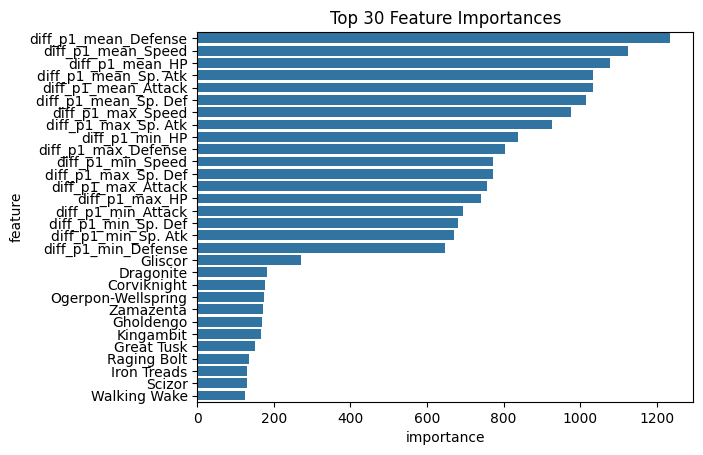

In [42]:
# Sacar el diagrama de barras de las importancias de las features de lightgbm
importances = model.feature_importances_
idx_to_pokemon = {v: k for k, v in pokemon_to_idx.items()}
sparse_feature_names = [idx_to_pokemon[i] for i in range(len(idx_to_pokemon))]
feature_names = sparse_feature_names + list(X_train_stats.columns)
feature_importances = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})
##ordenar por importancia
feature_importances = feature_importances.sort_values("importance", ascending=False)
sns.barplot(
    x="importance",
    y="feature",
    data=feature_importances.head(30)
)
plt.title("Top 30 Feature Importances")



In [43]:
for f, imp in zip(feature_names, importances):
    if "diff" in f:
        print(f, imp)

diff_p1_mean_HP 1079
diff_p1_max_HP 741
diff_p1_min_HP 837
diff_p1_mean_Attack 1033
diff_p1_max_Attack 757
diff_p1_min_Attack 695
diff_p1_mean_Defense 1234
diff_p1_max_Defense 803
diff_p1_min_Defense 646
diff_p1_mean_Sp. Atk 1033
diff_p1_max_Sp. Atk 926
diff_p1_min_Sp. Atk 671
diff_p1_mean_Sp. Def 1015
diff_p1_max_Sp. Def 772
diff_p1_min_Sp. Def 681
diff_p1_mean_Speed 1125
diff_p1_max_Speed 976
diff_p1_min_Speed 772


## 2. Features individuales derivadas

Se generan variables derivadas a nivel individual de sus stats

In [44]:
df_stats_individual_features = df_stats.copy()

In [45]:
def add_individual_features(df, prefix):
    """
    prefix: 'p1' o 'p2'
    """
    for i in range(1, 7):
        hp = df[f'HP_{prefix}_{i}']
        atk = df[f'Attack_{prefix}_{i}']
        defense = df[f'Defense_{prefix}_{i}']
        spa = df[f'Sp. Atk_{prefix}_{i}']
        spd = df[f'Sp. Def_{prefix}_{i}']
        spe = df[f'Speed_{prefix}_{i}']

        # Features
        df[f'physical_bulk_{prefix}_{i}'] = hp * defense
        df[f'special_bulk_{prefix}_{i}'] = hp * spd
        df[f'mixed_bulk_{prefix}_{i}'] = hp * (defense + spd) / 2

        df[f'offense_{prefix}_{i}'] = np.maximum(atk, spa)
        df[f'offense_bias_{prefix}_{i}'] = atk - spa

        df[f'fast_offense_{prefix}_{i}'] = df[f'offense_{prefix}_{i}'] * spe

    return df

In [46]:
df_stats_individual_features = add_individual_features(df_stats_individual_features, 'p1')
df_stats_individual_features = add_individual_features(df_stats_individual_features, 'p2')

In [47]:
df_stats_individual_features.head()

,battle_id,p1_poke1,p1_poke2,p1_poke3,p1_poke4,p1_poke5,p1_poke6,p2_poke1,p2_poke2,p2_poke3,...,mixed_bulk_p2_5,offense_p2_5,offense_bias_p2_5,fast_offense_p2_5,physical_bulk_p2_6,special_bulk_p2_6,mixed_bulk_p2_6,offense_p2_6,offense_bias_p2_6,fast_offense_p2_6
0,83362-gen9ou-2484742250,Krookodile,Kommo-o,Araquanid,Inteleon,Noivern,Muk-Alola,Alomomola,Slowking-Galar,Corviknight,...,5643.0,136,-46,3944,8645,9100,8872.5,134,34,10720
1,gen9ou-2008544089,Ninetales-Alola,Manaphy,Kommo-o,Iron Valiant,Samurott-Hisui,Kingambit,Pawmot,Samurott-Hisui,Toxapex,...,7938.0,111,-25,6660,15065,6095,10580.0,131,78,11397
2,gen9ou-2032727153,Serperior,Darkrai,Zapdos,Dragapult,Iron Valiant,Kingambit,Cresselia,Garganacl,Blissey,...,6825.0,80,40,5600,4800,3600,4200.0,130,70,9100
3,gen9ou-2301833199,Ogerpon-Wellspring,Gholdengo,Glimmora,Raging Bolt,Iron Moth,Dragonite,Pelipper,Talonflame,Barraskewda,...,10000.0,100,0,10000,9919,9047,9483.0,103,-39,4635
4,gen9ou-2346353253,Garchomp,Slowking-Galar,Gholdengo,Moltres,Iron Valiant,Kingambit,Ceruledge,Rillaboom,Hatterene,...,6300.0,130,75,8450,5850,4914,5382.0,92,18,10856


## 3. Conteo de roles en cada equipo

Se crean las características derivadas en el dataset de stats para definir los cuantiles altos en cada stat derivada para así poder definir que pokémon pertenecen a cada rol. Luego se cuentan el número de pokémon de cada rol en cada equipo para cada combate.

In [48]:
stats_calculated_features_df = stats_df.copy()

stats_calculated_features_df["physical_bulk"] = stats_calculated_features_df["HP"] * stats_calculated_features_df["Defense"]
stats_calculated_features_df["special_bulk"] = stats_calculated_features_df["HP"] * stats_calculated_features_df["Sp. Def"]
stats_calculated_features_df["mixed_bulk"] = stats_calculated_features_df["HP"] * (stats_calculated_features_df["Defense"] + stats_calculated_features_df["Sp. Def"]) / 2

stats_calculated_features_df["offense"] = stats_calculated_features_df[["Attack", "Sp. Atk"]].max(axis=1)
stats_calculated_features_df["offense_bias"] = stats_calculated_features_df["Attack"] - stats_calculated_features_df["Sp. Atk"]

stats_calculated_features_df["fast_offense"] = stats_calculated_features_df["offense"] * stats_calculated_features_df["Speed"]

In [49]:
# Celda 2
stats_calculated_features_df.head()

,pokemon_name,form,Type1,Type2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,physical_bulk,special_bulk,mixed_bulk,offense,offense_bias,fast_offense
0,Bulbasaur,,Grass,Poison,45,49,49,65,65,45,2205,2925,2565.0,65,-16,2925
1,Ivysaur,,Grass,Poison,60,62,63,80,80,60,3780,4800,4290.0,80,-18,4800
2,Venusaur,,Grass,Poison,80,82,83,100,100,80,6640,8000,7320.0,100,-18,8000
3,Charmander,,Fire,,39,52,43,60,50,65,1677,1950,1813.5,60,-8,3900
4,Charmeleon,,Fire,,58,64,58,80,65,80,3364,3770,3567.0,80,-16,6400


In [50]:
FAST_SPE = stats_calculated_features_df["Speed"].quantile(0.75)
HIGH_OFFENSE = stats_calculated_features_df["offense"].quantile(0.75)

BREAKER_ATK = stats_calculated_features_df["Attack"].quantile(0.80)
BREAKER_SPA = stats_calculated_features_df["Sp. Atk"].quantile(0.80)

SWEEPER_SCORE = stats_calculated_features_df["fast_offense"].quantile(0.75)

LOW_SPEED_WALL = stats_calculated_features_df["Speed"].quantile(0.50)
MIXED_BULK = stats_calculated_features_df["mixed_bulk"].quantile(0.75)

PHYS_WALL_BULK = stats_calculated_features_df["physical_bulk"].quantile(0.75)
SPEC_WALL_BULK = stats_calculated_features_df["special_bulk"].quantile(0.75)

thresholds = {
    "FAST_SPE": FAST_SPE,
    "HIGH_OFFENSE": HIGH_OFFENSE,
    "BREAKER_ATK": BREAKER_ATK,
    "BREAKER_SPA": BREAKER_SPA,
    "SWEEPER_SCORE": SWEEPER_SCORE,
    "LOW_SPEED_WALL": LOW_SPEED_WALL,
    "MIXED_BULK": MIXED_BULK,
    "PHYS_WALL_BULK": PHYS_WALL_BULK,
    "SPEC_WALL_BULK": SPEC_WALL_BULK
}

print("Cuantiles para definir roles:")
print(f"Fast Spe: {FAST_SPE}")
print(f"High Offense: {HIGH_OFFENSE}")
print(f"Breaker Atk: {BREAKER_ATK}")
print(f"Breaker SpA: {BREAKER_SPA}")
print(f"Sweeper Score: {SWEEPER_SCORE}")
print(f"Low Speed Wall: {LOW_SPEED_WALL}")
print(f"Mixed Wall Bulk: {MIXED_BULK}")
print(f"Physical Wall Bulk: {PHYS_WALL_BULK}")
print(f"Special Wall Bulk: {SPEC_WALL_BULK}")

Cuantiles para definir roles:
Fast Spe: 92.0
High Offense: 115.0
Breaker Atk: 110.0
Breaker SpA: 100.0
Sweeper Score: 9720.0
Low Speed Wall: 69.0
Mixed Wall Bulk: 7500.0
Physical Wall Bulk: 7600.0
Special Wall Bulk: 7212.5


### 3.1 Visualización de los Pokémon pertenecientes a cada rol

A continuación se crean sets de los pokémon pertenecientes a cada rol para la visualización de los mismos y el posible reajuste de los cuantiles usados para definir cada rol.

In [51]:
def build_role_sets(stats_df, thresholds):
    role_sets = {
        "fast": set(),
        "sweepers": set(),
        "physical_breakers": set(),
        "special_breakers": set(),
        "physical_walls": set(),
        "special_walls": set(),
        "slow_walls": set()
    }

    for _, row in stats_df.iterrows():
        name = row["pokemon_name"]

        spe = row["Speed"]
        atk = row["Attack"]
        spa = row["Sp. Atk"]
        phys_bulk = row["physical_bulk"]
        spec_bulk = row["special_bulk"]
        mixed_bulk = row["mixed_bulk"]
        offense = row["offense"]
        fast_off = row["fast_offense"]

        #  Fast
        if spe >= thresholds["FAST_SPE"]:
            role_sets["fast"].add(name)

        #  Sweepers
        if fast_off >= thresholds["SWEEPER_SCORE"]:
            role_sets["sweepers"].add(name)

        #  Physical breaker
        if (atk >= thresholds["BREAKER_ATK"]) and ((atk - spa) >= 15):
            role_sets["physical_breakers"].add(name)

        #  Special breaker
        if (spa >= thresholds["BREAKER_SPA"]) and ((spa - atk) >= 15):
            role_sets["special_breakers"].add(name)

        #  Walls
        if phys_bulk >= thresholds["PHYS_WALL_BULK"]:
            role_sets["physical_walls"].add(name)

        if spec_bulk >= thresholds["SPEC_WALL_BULK"]:
            role_sets["special_walls"].add(name)

        #  Slow walls 
        if (mixed_bulk >= thresholds["MIXED_BULK"]) and (spe <= thresholds["LOW_SPEED_WALL"]):
            role_sets["slow_walls"].add(name)

    return role_sets

In [52]:
role_sets = build_role_sets(stats_calculated_features_df, thresholds)

In [53]:
role_sets_json = {
    role: sorted(list(pokemons))
    for role, pokemons in role_sets.items()
}

# Guardar en archivo
output_path = "../json/pokemon_role_sets.json"

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(role_sets_json, f, indent=4, ensure_ascii=False)

### 3.2 Asignación de roles a cada Pokémon en dataset de combates

In [54]:
def add_role_features_from_thresholds(df, thresholds):
    df = df.copy()

    role_names = [
        "fast",
        "sweepers",
        "physical_breakers",
        "special_breakers",
        "physical_walls",
        "special_walls",
        "slow_walls"
    ]

    # estructura de salida (listas)
    results = {
        f"n_{role}_p1": [] for role in role_names
    }
    results.update({
        f"n_{role}_p2": [] for role in role_names
    })

    for _, row in df.iterrows():

        counts = {
            "p1": {r: 0 for r in role_names},
            "p2": {r: 0 for r in role_names}
        }

        for i in range(1, 7):

            for player in ["p1", "p2"]:

                spe = row[f"Speed_{player}_{i}"]
                atk = row[f"Attack_{player}_{i}"]
                spa = row[f"Sp. Atk_{player}_{i}"]
                phys_bulk = row[f"physical_bulk_{player}_{i}"]
                spec_bulk = row[f"special_bulk_{player}_{i}"]
                mixed_bulk = row[f"mixed_bulk_{player}_{i}"]
                fast_off = row[f"fast_offense_{player}_{i}"]

                # FAST
                if spe >= thresholds["FAST_SPE"]:
                    counts[player]["fast"] += 1

                # SWEEPERS
                if fast_off >= thresholds["SWEEPER_SCORE"]:
                    counts[player]["sweepers"] += 1

                # BREAKERS
                if (atk >= thresholds["BREAKER_ATK"]) and ((atk - spa) >= 15):
                    counts[player]["physical_breakers"] += 1

                if (spa >= thresholds["BREAKER_SPA"]) and ((spa - atk) >= 15):
                    counts[player]["special_breakers"] += 1

                # WALLS
                if phys_bulk >= thresholds["PHYS_WALL_BULK"]:
                    counts[player]["physical_walls"] += 1

                if spec_bulk >= thresholds["SPEC_WALL_BULK"]:
                    counts[player]["special_walls"] += 1

                # SLOW WALLS
                if (mixed_bulk >= thresholds["PHYS_WALL_BULK"]) and (spe <= thresholds["LOW_SPEED_WALL"]):
                    counts[player]["slow_walls"] += 1

        # guardar resultados (MUY importante: fuera de loops internos)
        for role in role_names:
            results[f"n_{role}_p1"].append(counts["p1"][role])
            results[f"n_{role}_p2"].append(counts["p2"][role])

    # asignación vectorizada final
    for k, v in results.items():
        df[k] = v

    return df

In [55]:
df_with_roles = add_role_features_from_thresholds(df_stats_individual_features, thresholds)

## 4. Medidas derivadas a nivel de equipo

Se obtienen la suma delos mayores dos valores en las stats velocidad, offense, y fast offense para cada equipo para obtener luego la diferencia entre ambos equipos en cada combate. La idea es que esta diferencia pueda ser un buen predictor de la victoria de un equipo sobre otro, ya que la velocidad y el offense son dos de las características más importantes a la hora de predecir el resultado de un combate.

In [56]:
def compute_team_topk_features(df, prefix):
    top2_speed = []
    top2_offense = []
    top2_fast_offense = []

    for _, row in df.iterrows():

        speeds = []
        offenses = []
        fast_offenses = []

        for i in range(1, 7):
            speeds.append(row[f"Speed_{prefix}_{i}"])
            offenses.append(row[f"offense_{prefix}_{i}"])
            fast_offenses.append(row[f"fast_offense_{prefix}_{i}"])

        top2_speed.append(np.sort(speeds)[-2:].sum())
        top2_offense.append(np.sort(offenses)[-2:].sum())
        top2_fast_offense.append(np.sort(fast_offenses)[-2:].sum())

    return {
        "top2_speed": top2_speed,
        "top2_offense": top2_offense,
        "top2_fast_offense": top2_fast_offense
    }

In [57]:
df_team_features = df_with_roles.copy()

p1_topk = compute_team_topk_features(df_team_features, "p1")
p2_topk = compute_team_topk_features(df_team_features, "p2")

Se añaden las diferencias de estas características al dataset de combates con roles para su uso en el modelo de predicción.

In [58]:
df_team_features["diff_sum_top2_speed"] = np.array(p1_topk["top2_speed"]) - np.array(p2_topk["top2_speed"])

df_team_features["diff_sum_top2_offense"] = np.array(p1_topk["top2_offense"]) - np.array(p2_topk["top2_offense"])

df_team_features["diff_sum_top2_fast_offense"] = np.array(p1_topk["top2_fast_offense"]) - np.array(p2_topk["top2_fast_offense"])

Además, se añaden las diferencias en número de sweepers y de walls entre ambos equipos para cada combate.

In [59]:
df_team_features["diff_n_sweepers"] = df_team_features["n_sweepers_p1"] - df_team_features["n_sweepers_p2"]

df_team_features["diff_n_walls"] = (
    (df_team_features["n_physical_walls_p1"] + df_team_features["n_special_walls_p1"] + df_team_features["n_slow_walls_p1"]) -
    (df_team_features["n_physical_walls_p2"] + df_team_features["n_special_walls_p2"] + df_team_features["n_slow_walls_p2"])
)

In [60]:
cols = [
    "diff_sum_top2_speed",
    "diff_sum_top2_offense",
    "diff_sum_top2_fast_offense",
    "diff_n_sweepers",
    "diff_n_walls"
]

df_team_features[cols].head()

,diff_sum_top2_speed,diff_sum_top2_offense,diff_sum_top2_fast_offense,diff_n_sweepers,diff_n_walls
0,61,-28,2951,1,-5
1,11,9,-620,-1,2
2,112,40,18440,4,-6
3,-42,29,-628,2,1
4,13,1,6087,0,9


## 5. Variables debilidades y resistencias de tipos

In [63]:
import json

with open("../json/type_chart.json", "r") as f:
    type_chart = json.load(f)

A continuacion se crearán features derivadas con la efectividad de los tipos de los pokemon de cada equipo contra los tipos del equipo contrario. 

In [64]:
types = sorted(set(
    df_team_features[[col for col in df_team_features.columns if "Type1" in col or "Type2" in col]]
    .stack()
    .dropna()
))

type_to_idx = {t: i for i, t in enumerate(types)}
n_types = len(types)

In [65]:
type_matrix = np.ones((n_types, n_types))

for att_type, defenders in type_chart.items():
    for def_type, mult in defenders.items():
        type_matrix[type_to_idx[att_type], type_to_idx[def_type]] = mult

In [66]:
def extract_team_types(df, prefix):
    t1 = np.stack([df[f"Type1_{prefix}_{i}"].map(type_to_idx).values for i in range(1, 7)], axis=1)
    t2 = np.stack([df[f"Type2_{prefix}_{i}"].map(type_to_idx).fillna(-1).values for i in range(1, 7)], axis=1)
    return t1, t2

p1_t1, p1_t2 = extract_team_types(df_team_features, "p1")
p2_t1, p2_t2 = extract_team_types(df_team_features, "p2")

Se define función que obtenga la efectividad  un pokémon atacante contra un pokémon defensor a partir de sus tipos y la tabla de efectividades entre tipos.

In [67]:
from numba import njit

@njit
def compute_features_numba(p1_t1, p1_t2, p2_t1, p2_t2, type_matrix):
    N = p1_t1.shape[0]
    
    diff_sum = np.zeros(N)
    diff_super = np.zeros(N)
    diff_not = np.zeros(N)
    diff_min = np.zeros(N)
    
    for n in range(N):
        
        best_vs_p2 = np.zeros(6)
        best_vs_p1 = np.zeros(6)
        
        # --- P1 → P2 ---
        for j in range(6):
            best = 0.0
            
            for i in range(6):
                
                # tipo1 ataque
                mult1 = type_matrix[p1_t1[n, i], p2_t1[n, j]]
                
                if p2_t2[n, j] != -1:
                    mult1 *= type_matrix[p1_t1[n, i], p2_t2[n, j]]
                
                # tipo2 ataque
                mult2 = 1.0
                if p1_t2[n, i] != -1:
                    mult2 = type_matrix[p1_t2[n, i], p2_t1[n, j]]
                    
                    if p2_t2[n, j] != -1:
                        mult2 *= type_matrix[p1_t2[n, i], p2_t2[n, j]]
                
                best_attack = mult1 if mult1 > mult2 else mult2
                
                if best_attack > best:
                    best = best_attack
            
            best_vs_p2[j] = best
        
        # --- P2 → P1 ---
        for j in range(6):
            best = 0.0
            
            for i in range(6):
                
                mult1 = type_matrix[p2_t1[n, i], p1_t1[n, j]]
                
                if p1_t2[n, j] != -1:
                    mult1 *= type_matrix[p2_t1[n, i], p1_t2[n, j]]
                
                mult2 = 1.0
                if p2_t2[n, i] != -1:
                    mult2 = type_matrix[p2_t2[n, i], p1_t1[n, j]]
                    
                    if p1_t2[n, j] != -1:
                        mult2 *= type_matrix[p2_t2[n, i], p1_t2[n, j]]
                
                best_attack = mult1 if mult1 > mult2 else mult2
                
                if best_attack > best:
                    best = best_attack
            
            best_vs_p1[j] = best
        
        # --- features ---
        p1_sum = best_vs_p2.sum()
        p2_sum = best_vs_p1.sum()
        
        p1_super = (best_vs_p2 >= 2).sum()
        p2_super = (best_vs_p1 >= 2).sum()
        
        p1_not = (best_vs_p2 <= 0.5).sum()
        p2_not = (best_vs_p1 <= 0.5).sum()
        
        p1_min = best_vs_p2.min()
        p2_min = best_vs_p1.min()
        
        diff_sum[n] = p1_sum - p2_sum
        diff_super[n] = p1_super - p2_super
        diff_not[n] = p1_not - p2_not
        diff_min[n] = p1_min - p2_min
    
    return diff_sum, diff_super, diff_not, diff_min

Se obtienen las features: diff_best_pressure_sum (diferencia de la suma de los mejores multiplicadores de presión), diff_n_super_effective (diferencia del número de movimientos super efectivos), diff_n_not_effective (diferencia del número de movimientos poco efectivos) y diff_min_best_response (diferencia del peor caso de respuesta mejor).

In [71]:
p1_t1 = p1_t1.astype(np.int32)
p1_t2 = p1_t2.astype(np.int32)
p2_t1 = p2_t1.astype(np.int32)
p2_t2 = p2_t2.astype(np.int32)

type_matrix = type_matrix.astype(np.float32)


diff_sum, diff_super, diff_not, diff_min = compute_features_numba(
    p1_t1, p1_t2, p2_t1, p2_t2, type_matrix
)

df_team_features["diff_best_pressure_sum"] = diff_sum
df_team_features["diff_n_super_effective"] = diff_super
df_team_features["diff_n_not_effective"] = diff_not
df_team_features["diff_min_best_response"] = diff_min

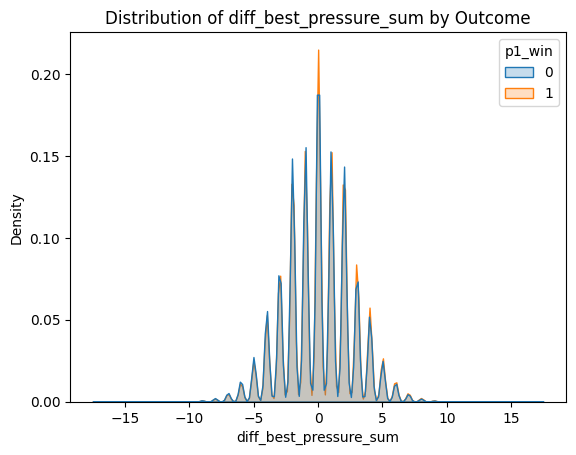

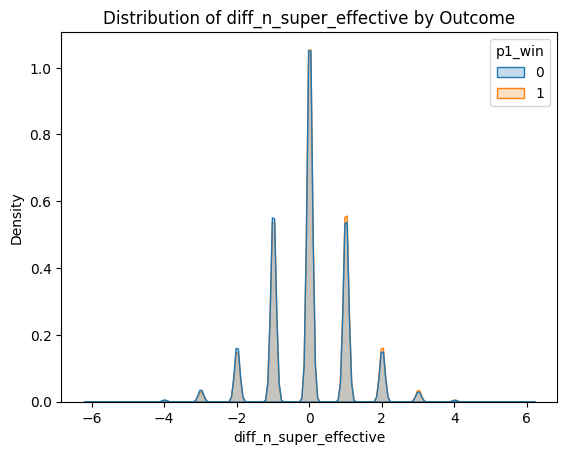

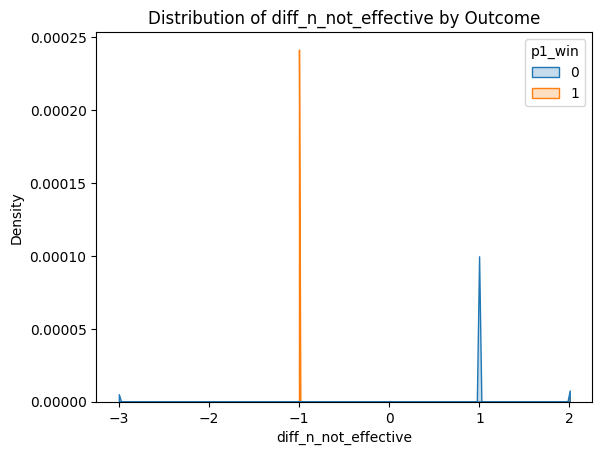

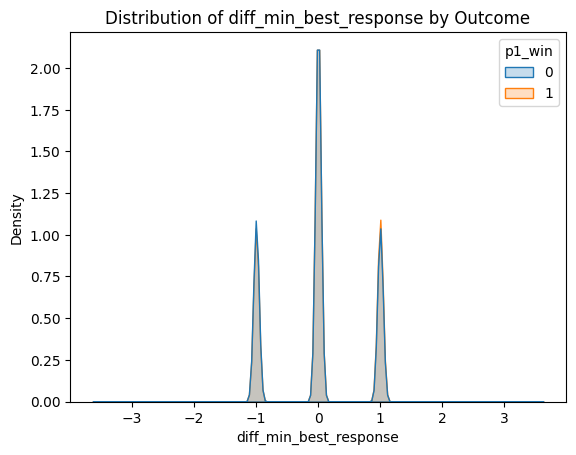

In [72]:
## Visualizacion de las nuevas features
new_cols = [
    "diff_best_pressure_sum",
    "diff_n_super_effective",
    "diff_n_not_effective",
    "diff_min_best_response"
]
for col in new_cols:
    sns.kdeplot(data=df_team_features, x=col, hue="p1_win", fill=True)
    plt.title(f"Distribution of {col} by Outcome")
    plt.show()

## 6. Guardado del dataset final con características derivadas a nivel de equipo para su uso en el modelo de predicción

In [73]:
df_final = pd.concat(
    [df_team_features, diff_df],
    axis=1
)

In [74]:
df_final.to_csv("../data/gen9ou_aggregated_features_dataset.csv", index=False)